<a href="https://colab.research.google.com/github/Ashok-nimmala/EXAPLAINABLE-AI/blob/main/research3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import zipfile
from PIL import Image
import os
from datetime import datetime

zip_path = '/content/drive/MyDrive/pnemonia.zip'  # update path if needed

records = []

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    file_list = zip_ref.namelist()

    # Filter for image files
    img_files = [f for f in file_list if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    for i, img_filename in enumerate(img_files):
        # --- Assign label based on folder name inside zip ---
        if "normal" in img_filename.lower():
            label = 0
        elif "pneumonia" in img_filename.lower():
            label = 1
        else:
            continue  # skip unknown folders

        # --- Assign patient_id ---
        # Example: "person123_bacteria_1.jpeg" → patient123
        base = os.path.basename(img_filename)
        patient_id = base.split("_")[0]

        # --- Assign timestamp ---
        # If no date in filename, use index as pseudo-time
        try:
            ts = datetime.strptime(base.split('.')[0], "%Y%m%d")
        except:
            ts = datetime.fromtimestamp(i)

        records.append({
            "patient_id": patient_id,
            "image_path": img_filename,  # store inside-zip path
            "timestamp": ts,
            "label": label
        })

print(f"Built {len(records)} records from {zip_path}")




Built 23074 records from /content/drive/MyDrive/pnemonia.zip


In [5]:
from collections import defaultdict

def group_by_patient(records):
    """
    Groups records by patient_id and sorts each patient's records by timestamp.
    """
    patients = defaultdict(list)
    for rec in records:
        patients[rec["patient_id"]].append(rec)

    # Sort each patient's records by timestamp
    for pid in patients:
        patients[pid] = sorted(patients[pid], key=lambda x: x["timestamp"])

    return patients


In [6]:
patients = group_by_patient(records)
print(f"Patients found: {len(patients)}")


Patients found: 11537


In [11]:
!pip install torch-geometric

In [42]:

# Utilities: create temporal graphs and convert to PyG Data objects.
import os, numpy as np, torch
from PIL import Image
from skimage.transform import resize
import networkx as nx
from torch_geometric.data import Data, InMemoryDataset

def load_image(path, target_size=(224,224)):
    img = Image.open(path).convert('L')  # grayscale X-ray
    arr = np.array(img)
    arr = resize(arr, target_size, preserve_range=True).astype(np.float32) / 255.0
    # Expand channel dimension
    return arr[np.newaxis, ...]

def group_by_patient(records):
    # records : list of dicts with keys: {'patient_id','image_path','timestamp', 'label'}
    patients = {}
    for r in records:
        patients.setdefault(r['patient_id'], []).append(r)
    # sort by timestamp
    for pid in patients:
        patients[pid].sort(key=lambda x: x['timestamp'])
    return patients

def build_temporal_graph_for_patient(patient_records, feature_extractor=None):
    # patient_records: list of record dicts for one patient (sorted by time)
    # feature_extractor: callable(image_array)->feature_vector. If None, flatten small image.
    node_feats = []
    labels = []
    edge_index = [[], []]
    for i, rec in enumerate(patient_records):
        img = load_image(rec['image_path'])
        if feature_extractor is None:
            feat = img.reshape(-1)[:4096]  # simple flatten (trim/pad to 4096)
            if feat.size < 4096:
                feat = np.pad(feat, (0, 4096-feat.size))
            feat = feat.astype(np.float32)
        else:
            feat = feature_extractor(img)
        node_feats.append(feat)
        labels.append(rec.get('label', 0))
        # connect consecutive timepoints (bidirectional)
        if i>0:
            edge_index[0].extend([i-1, i])
            edge_index[1].extend([i, i-1])
    if len(node_feats)==0:
        return None
    x = torch.tensor(np.vstack(node_feats), dtype=torch.float)
    edge_index = torch.tensor(edge_index, dtype=torch.long)
    y = torch.tensor(labels, dtype=torch.long)
    data = Data(x=x, edge_index=edge_index, y=y)
    # store metadata
    data.patient_id = patient_records[0]['patient_id']
    data.timestamps = [r['timestamp'] for r in patient_records]
    data.image_paths = [r['image_path'] for r in patient_records]
    return data

class TemporalXrayDataset(InMemoryDataset):
    def __init__(self, patient_groups, transform=None, pre_transform=None, feature_extractor=None):
        super().__init__(None, transform, pre_transform)
        self.data_list = []
        for pid, recs in patient_groups.items():
            d = build_temporal_graph_for_patient(recs, feature_extractor=feature_extractor)
            if d is not None:
                self.data_list.append(d)
        self.data, self.slices = self.collate(self.data_list)

    def get(self, idx):
        return self.data_list[idx]

# Example usage (you must adapt records to your notebook's variables):
# records = [{'patient_id':'p1','image_path':'/content/img1.png','timestamp':'2020-01-01','label':1}, ...]
# patients = group_by_patient(records)
# dataset = TemporalXrayDataset(patients)


In [22]:

import torch
import torch.nn.functional as F
from torch_geometric.nn import GATConv, global_mean_pool
from torch_geometric.explain import GNNExplainer

class TemporalGAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels=64, out_channels=2, heads=4, dropout=0.2):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, concat=True)
        self.conv2 = GATConv(hidden_channels*heads, hidden_channels, heads=1, concat=True)
        self.lin = torch.nn.Linear(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index, batch=None):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        # If batched temporal graphs are used, pool per graph
        if batch is not None:
            x = global_mean_pool(x, batch)
        else:
            # If single graph per forward, average node embeddings
            x = x.mean(dim=0, keepdim=True)
        out = self.lin(x)
        return out

# Explainability example:
def explain_graph(model, data, index_to_explain=0, epochs=200):
    explainer = GNNExplainer(model, epochs=epochs)
    node_feat_mask, edge_mask = explainer.explain_graph(data.x, data.edge_index)
    return node_feat_mask, edge_mask


In [38]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from torch_geometric.loader import DataLoader

def train(model, loader, optimizer, device='cpu'):
    model.train()
    losses = []
    for data in loader:
        data = data.to(device)
        # Ensure batch is created correctly for single graph in batch
        batch = torch.zeros(data.x.size(0), dtype=torch.long).to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, batch=batch)
        # assume y is per-graph: take first element
        y = data.y[0].to(device).unsqueeze(0)
        loss = F.cross_entropy(out, y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return float(np.mean(losses)) if losses else 0.0

def evaluate(model, loader, device='cpu'):
    model.eval()
    ys = []
    preds = []
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            # Ensure batch is created correctly for single graph in batch
            batch = torch.zeros(data.x.size(0), dtype=torch.long).to(device)
            out = model(data.x, data.edge_index, batch=batch)
            prob = F.softmax(out, dim=1).cpu().numpy()
            pred = prob.argmax(axis=1)[0]
            preds.append(pred)
            ys.append(int(data.y[0].cpu().item()))
    acc = accuracy_score(ys, preds) if ys else 0.0
    f1 = f1_score(ys, preds, zero_division=0) if ys else 0.0
    # AUC requires probability for positive class and at least two classes in ys
    try:
        # Adjusting for single sample prediction
        prob_positive_class = [p[1] for p in prob]
        if len(set(ys)) > 1 and len(ys) > 1: # Ensure at least two different classes and more than one sample
             auc = roc_auc_score(ys, prob_positive_class)
        else:
             auc = None
    except Exception as e:
        print(f"Could not calculate AUC: {e}")
        auc = None
    return {'accuracy':acc, 'f1':f1, 'auc':auc}

# Example training scaffold (adjust hyperparams for real training):
# dataset = TemporalXrayDataset(patients) # Dataset created in a previous cell
# loader = DataLoader(dataset.data_list, batch_size=1, shuffle=True) # DataLoader created in a previous cell
model = TemporalGAT(in_channels=4096, hidden_channels=64, out_channels=2)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

# Check if dataset and loader exist before training
if 'dataset' in locals() and 'loader' in locals() and len(dataset) > 0:
    # Use GPU if available
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)

    print(f"Starting training on {device}...")
    for epoch in range(10):
        loss = train(model, loader, optimizer, device=device)
        metrics = evaluate(model, loader, device=device)
        print(f"Epoch {epoch+1}: Loss = {loss:.4f}, Metrics = {metrics}")
else:
    print("Dataset or DataLoader not found or empty. Please create them first.")

Dataset or DataLoader not found or empty. Please create them first.


In [25]:

import matplotlib.pyplot as plt
import numpy as np

def overlay_heatmap_on_image(image_path, patch_importances, patch_grid=(4,4)):
    # image_path: original xray
    # patch_importances: list or array with length = patch_grid[0]*patch_grid[1]
    img = Image.open(image_path).convert('L')
    img_arr = np.array(img, dtype=float)
    H, W = img_arr.shape
    ph, pw = H//patch_grid[0], W//patch_grid[1]
    heatmap = np.zeros_like(img_arr, dtype=float)
    idx = 0
    for i in range(patch_grid[0]):
        for j in range(patch_grid[1]):
            y0, y1 = i*ph, (i+1)*ph
            x0, x1 = j*pw, (j+1)*pw
            heatmap[y0:y1, x0:x1] = patch_importances[idx]
            idx += 1
    # Normalize heatmap
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
    plt.figure(figsize=(6,6))
    plt.imshow(img_arr, cmap='gray')
    plt.imshow(heatmap, alpha=0.5)
    plt.title('Explanation overlay (patch importances)')
    plt.axis('off')
    plt.show()


In [36]:
# ----- Add this cell to researchF.ipynb -----
# Disease Evolution Graph Visualizations (static matplotlib + networkx)
# Input: list_of_pil_images (PIL.Image) or torch tensors (C,H,W) per patient
# Output: matplotlib figure saved & shown inline

import math
import io
from typing import List, Optional, Tuple
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

import torch
import torch.nn as nn
import torchvision.transforms as T
from torchvision import models

# ----------------- Utilities / Encoder -----------------
class DefaultResNetEncoder(nn.Module):
    """Simple ResNet18-based encoder returning L2-normalized 256-d vectors per image."""
    def __init__(self, out_dim: int = 256, pretrained: bool = True, device: Optional[torch.device] = None):
        super().__init__()
        self.device = device or (torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu'))
        res = models.resnet18(pretrained=pretrained)
        # drop classifier
        in_feat = res.fc.in_features
        modules = list(res.children())[:-1]   # remove avgpool+fc, or keep avgpool? we will keep avgpool by using last layer
        self.backbone = nn.Sequential(*modules)  # outputs (B,512,1,1)
        self.projector = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_feat, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, out_dim)
        )
        self.to(self.device)
        self.eval()
        # transforms for PIL images
        self.transform = T.Compose([
            T.Resize((224,224)),
            T.ToTensor(),
            T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
        ])

    def encode_pil(self, pil_img: Image.Image) -> np.ndarray:
        x = self.transform(pil_img).unsqueeze(0).to(self.device)
        with torch.no_grad():
            feat_map = self.backbone(x)            # (1, 512, 1, 1)
            # flatten and project
            z = self.projector(feat_map.view(1, -1))  # (1, out_dim)
            z = z.squeeze(0).cpu().numpy()
        # L2-normalize
        z = z / (np.linalg.norm(z) + 1e-10)
        return z

    def encode_tensor(self, tensor_img: torch.Tensor) -> np.ndarray:
        # tensor_img expected C,H,W in [0,1] range (not normalized)
        pil = T.ToPILImage()(tensor_img.cpu())
        return self.encode_pil(pil)

# ----------------- Graph building / progression scoring -----------------
def build_patient_graph(images: List, timestamps: Optional[List] = None,
                        encoder: Optional[nn.Module] = None,
                        long_range: bool = False,
                        long_range_thresh: float = 0.25) -> Tuple[nx.DiGraph, List[np.ndarray]]:
    """
    images: list of PIL.Image or torch.Tensor (CxHxW)
    timestamps: optional list of timepoints (any sortable values). If None, uses indices.
    encoder: if None, uses DefaultResNetEncoder(pretrained=True)
    long_range: whether to add non-consecutive edges if progression is large
    long_range_thresh: threshold on embedding delta (normalized) to add long-range edge
    Returns: directed graph (time forward) and list of embeddings (ordered)
    """
    if encoder is None:
        encoder = DefaultResNetEncoder(pretrained=True)

    # normalize timestamps
    if timestamps is None:
        timestamps = list(range(len(images)))
    assert len(images) == len(timestamps)

    # compute embeddings
    embeddings = []
    for img in images:
        if isinstance(img, torch.Tensor):
            vec = encoder.encode_tensor(img)
        else:
            vec = encoder.encode_pil(img)
        embeddings.append(vec)

    # build directed graph with nodes ordered by time
    # nodes: 0..T-1, with attributes: ts, emb, severity_score (computed), thumbnail (PIL)
    G = nx.DiGraph()
    Tn = len(images)
    for i in range(Tn):
        G.add_node(i, ts=timestamps[i], emb=embeddings[i], thumb=images[i])

    # create edges between consecutive timepoints
    # edge weight = progression magnitude = ||emb_{t+1} - emb_t|| (cosine -> use 1 - dot because normalized)
    for i in range(Tn - 1):
        e = 1.0 - float(np.dot(embeddings[i], embeddings[i+1]))  # cosine distance in [0,2]
        # normalize to 0..1 roughly by dividing by 2
        w = e / 2.0
        G.add_edge(i, i+1, weight=w, type='temporal')

    # optional: add long-range edges when big change detected
    if long_range:
        for i in range(Tn):
            for j in range(i+2, Tn):
                e = 1.0 - float(np.dot(embeddings[i], embeddings[j]))
                w = e / 2.0
                if w >= long_range_thresh:
                    G.add_edge(i, j, weight=w, type='long_range')

    return G, embeddings

# ----------------- Simple progression summary per node -----------------
def compute_node_severity(embeddings: List[np.ndarray], baseline_idx: int = 0) -> List[float]:
    """
    A simple severity proxy: distance from baseline embedding (cosine distance).
    Returns list of normalized severity scores 0..1 (min-max scaled).
    """
    base = embeddings[baseline_idx]
    scores = [ (1.0 - float(np.dot(base, e))) / 2.0 for e in embeddings ]  # cosine dist -> ~[0,1]
    # min-max normalize
    mn, mx = min(scores), max(scores)
    if mx - mn < 1e-8:
        return [0.0 for _ in scores]
    norm = [(s - mn) / (mx - mn) for s in scores]
    return norm

# ----------------- Visualization -----------------
def visualize_patient_evolution(G: nx.DiGraph, embeddings: List[np.ndarray],
                                title: str = "Patient disease evolution",
                                savepath: Optional[str] = None,
                                figsize: Tuple[int,int]=(12,4),
                                show_node_thumbnails: bool = True,
                                cmap=plt.cm.Reds):
    """
    Draws nodes along a horizontal time axis (x = time order), node thumbnails as insets,
    edges colored/thick by progression weight. Also prints a compact progression legend.
    """
    # node order sorted by timestamp
    nodes_sorted = sorted(G.nodes(data=True), key=lambda nv: nv[1]['ts'])
    indices = [n for n,_ in nodes_sorted]
    xs = list(range(len(indices)))  # x positions by time order
    ys = [0] * len(indices)

    # compute per-node severity
    thumbs = [G.nodes[i]['thumb'] for i in indices]
    severity = compute_node_severity(embeddings, baseline_idx=0)

    # build matplotlib figure
    fig, ax = plt.subplots(1,1, figsize=figsize)
    ax.set_title(title, fontsize=14)
    ax.set_ylim(-1, 1)
    ax.axis('off')

    # draw nodes (invisible points for layout)
    for xi, idx in zip(xs, indices):
        ax.plot(xi, 0, 'o', markersize=0)  # placeholder

    # draw edges with color/width by weight
    weights = [G[u][v]['weight'] for u,v in G.edges()]
    # normalize weights
    if len(weights) > 0:
        wmin, wmax = min(weights), max(weights)
        denom = (wmax - wmin) if (wmax - wmin) > 1e-6 else 1.0
    else:
        wmin, wmax, denom = 0.0, 1.0, 1.0

    for (u,v) in G.edges():
        ux = indices.index(u)
        vx = indices.index(v)
        w = G[u][v]['weight']
        norm = (w - wmin) / denom
        linewidth = 1 + 4*norm
        color = cmap(norm)
        ax.annotate("", xy=(vx, 0), xytext=(ux,0),
                    arrowprops=dict(arrowstyle="->", color=color, lw=linewidth, shrinkA=10, shrinkB=10))

    # add node thumbnails above axis
    if show_node_thumbnails:
        thumbnail_size = 0.18  # fraction of figure width
        fig_w_inch = fig.get_size_inches()[0]
        # compute thumbnail display size in axis coords
        for xi, idx, th, sev in zip(xs, indices, thumbs, severity):
            # convert PIL to array if needed
            if isinstance(th, torch.Tensor):
                th_img = T.ToPILImage()(th.cpu())
            else:
                th_img = th
            # create inset axes
            left = (xi / max(1, xs[-1])) * 0.95  # avoid extreme right cropping
            # place thumbnails above the axis (y ~ 0.2)
            inset_ax = fig.add_axes([0.05 + left*0.9, 0.55, 0.12, 0.36])  # manual placement tuned for typical figsize
            inset_ax.imshow(th_img.convert('L'), cmap='gray', vmin=0, vmax=255)
            inset_ax.axis('off')
            # put a small colored border proportional to severity
            bbox = inset_ax.get_position()
            # draw rectangle on main ax scaled to bbox coords
            rect = mpatches.Rectangle((bbox.x0, bbox.y0), bbox.width, bbox.height,
                                      fill=False, transform=fig.transFigure,
                                      linewidth=2, edgecolor=plt.cm.Reds(sev))
            fig.patches.append(rect)

    # add simple legend: edge color -> progression magnitude
    # create a mini colorbar legend
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=wmin, vmax=wmax))
    sm.set_array([])
    cax = fig.add_axes([0.85, 0.2, 0.03, 0.5])  # colorbar axis
    cbar = plt.colorbar(sm, cax=cax)
    cbar.set_label('Edge progression weight (higher = more change)', rotation=90)

    # add baseline severity text
    avg_sev = np.mean(severity)
    ax.text(0.02, -0.6, f"Avg severity (normalized) = {avg_sev:.3f}", transform=ax.transAxes)

    if savepath:
        plt.savefig(savepath, bbox_inches='tight', dpi=150)
    plt.show()
    return fig

# ----------------- End of cell. Example usage -----------------
# Example (uncomment and adapt to your data)
# patient_images = [Image.open(path) for path in patient_paths]  # or tensors
# timestamps = [datetime1, datetime2, ...]  # optional
# encoder = DefaultResNetEncoder(pretrained=True)
# G, embs = build_patient_graph(patient_images, timestamps=timestamps, encoder=encoder, long_range=True)
# fig = visualize_patient_evolution(G, embs, title="Patient 123 - Pneumonia progression", savepath="./patient123_evolution.png")


In [34]:
import torch
from torch_geometric.data import Data

# Example: severity calculation (dummy function, replace with CNN model output)
def compute_severity(patch_features):
    """
    patch_features: [num_nodes, feature_dim]
    Returns severity score per node in range [0,1] (higher = more severe).
    """
    # Here: simple example -> mean activation as severity
    severity = patch_features.mean(dim=1, keepdim=True)
    # Normalize 0-1
    severity = (severity - severity.min()) / (severity.max() - severity.min() + 1e-6)
    return severity

# Suppose you already extracted features from CNN encoder for patches
num_nodes = 10
feature_dim = 256
patch_features = torch.randn((num_nodes, feature_dim))  # CNN embeddings for patches

# Compute severity for each node
severity_scores = compute_severity(patch_features)  # shape [num_nodes, 1]

# Concatenate severity to original patch features
node_features = torch.cat([patch_features, severity_scores], dim=1)  # [num_nodes, feature_dim+1]

# Example edge index (toy: fully connected temporal graph)
edge_index = torch.tensor([
    [0,1, 1,2, 2,3, 3,4, 4,5, 5,6, 6,7, 7,8, 8,9],
    [1,0, 2,1, 3,2, 4,3, 5,4, 6,5, 7,6, 8,7, 9,8]
], dtype=torch.long)

# Build PyG graph with severity-augmented node features
data = Data(x=node_features, edge_index=edge_index)

print("Node feature shape:", data.x.shape)   # should be [num_nodes, 257]
print("Edge index shape:", data.edge_index.shape)
print("Severity (last column in x):", data.x[:, -1])


Node feature shape: torch.Size([10, 257])
Edge index shape: torch.Size([2, 18])
Severity (last column in x): tensor([0.6712, 0.5276, 0.0813, 0.4692, 0.3191, 0.0146, 0.3405, 0.0000, 0.4186,
        1.0000])


/tmp/ipython-input-2464605437.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('coolwarm') # Use cm.get_cmap


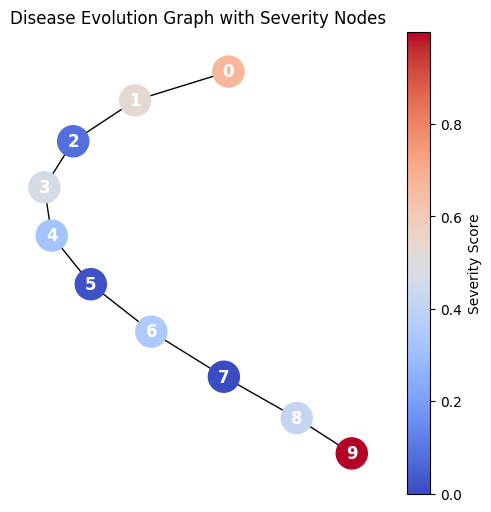

In [39]:
import networkx as nx
import matplotlib.pyplot as plt
import torch
import matplotlib.cm as cm # Import cm for colormaps

def visualize_severity_graph(data):
    """
    data: torch_geometric.data.Data with x (node features) and edge_index
    Assumes last column of x is severity score.
    """
    # Make sure edge_index is on CPU and numpy
    edge_index = data.edge_index.detach().cpu().numpy()

    # Create NetworkX graph
    G = nx.Graph()
    for i in range(edge_index.shape[1]):
        src, dst = int(edge_index[0, i]), int(edge_index[1, i])
        G.add_edge(src, dst)

    # Extract severity (last feature column)
    severity = data.x[:, -1].detach().cpu().numpy()

    # Node colors map to severity values
    cmap = cm.get_cmap('coolwarm') # Use cm.get_cmap
    node_colors = [cmap(s) for s in severity]

    # Draw
    fig, ax = plt.subplots(figsize=(6,6)) # Get figure and axes objects
    pos = nx.spring_layout(G, seed=42)  # force-directed layout
    nx.draw(
        G, pos,
        with_labels=True,
        node_color=node_colors,
        node_size=500,
        font_color="white",
        font_weight="bold",
        ax=ax # Specify the axes to draw on
    )
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=severity.min(), vmax=severity.max()))
    sm.set_array([]) # Needed for the colorbar to work correctly
    plt.colorbar(sm, ax=ax, label="Severity Score") # Specify the axes and mappable
    plt.title("Disease Evolution Graph with Severity Nodes")
    plt.show()

# Example call
visualize_severity_graph(data)